# MDSSP Canvas Visualization

This notebook visualizes the tile placement on canvas from the MDSSP solver solution output.

We'll load the solution from `solution.json` and create interactive visualizations showing:
- The complete canvas with all tiles placed
- Individual tile placements with coordinates
- Statistics about the solution


## 1. Import Required Libraries

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from collections import defaultdict

# Set up matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline


## 2. Load Solution Data from JSON

In [2]:
# Load solution data
with open('results.json', 'r') as f:
    solution_data = json.load(f)

# Load dataset to get tile information
with open('dataset.json', 'r') as f:
    dataset = json.load(f)

print("Solution loaded successfully!")
print(f"Number of results: {len(solution_data['results'])}")
for result in solution_data['results']:
    print(f"  - Algorithm: {result['algorithm']}, Status: {result['status']}")


Solution loaded successfully!
Number of results: 1
  - Algorithm: Greedy, Status: success


## 3. Parse Tile Placement Information

In [ ]:
# Select first result (or you can choose a specific algorithm)
result = solution_data['results'][0]

algorithm = result['algorithm']
objective = result['objective']
bbox_width = result['bbox_width']
bbox_height = result['bbox_height']
placements = result['placements']

print(f"Algorithm: {algorithm}")
print(f"Objective (L): {objective}")
print(f"Bounding Box: {bbox_width} × {bbox_height}")
print(f"Number of tiles placed: {len(placements)}")
print(f"Verified: {result.get('verified', 'N/A')}")

# Extract tiles data
tiles_data = dataset['tiles']
print(f"\nTotal tiles in dataset: {len(tiles_data)}")

# Debug: check tile_id range in placements
if placements:
    tile_ids = [p['tile_id'] for p in placements]
    print(f"Tile IDs range: min={min(tile_ids)}, max={max(tile_ids)}")
    print(f"Sample tile IDs: {tile_ids[:5]}")


Algorithm: Greedy
Objective (L): 113
Bounding Box: 113 × 113
Number of tiles placed: 4096
Verified: True

Total tiles in dataset: 80


## 4. Reconstruct the Canvas

We'll reconstruct the canvas by placing each tile at its specified position.

In [ ]:
# Build the canvas from placements
canvas = {}  # Dictionary to store (x, y) -> value
overlap_count = defaultdict(int)  # Track overlaps

for placement in placements:
    tile_id = placement['tile_id']
    pos_x = placement['x']
    pos_y = placement['y']
    
    # Get the tile data - check if tile_id is valid
    if tile_id < 0 or tile_id >= len(tiles_data):
        print(f"Warning: Invalid tile_id {tile_id}, skipping...")
        continue
    
    tile = tiles_data[tile_id]
    
    # Place tile on canvas
    for row_idx, row in enumerate(tile):
        for col_idx, cell_value in enumerate(row):
            if cell_value == 1:  # Only place '1' cells
                x = pos_x + col_idx
                y = pos_y + row_idx
                
                if (x, y) in canvas:
                    overlap_count[(x, y)] += 1
                else:
                    canvas[(x, y)] = cell_value
                    overlap_count[(x, y)] = 1

print(f"Canvas cells occupied: {len(canvas)}")
print(f"Cells with overlaps: {sum(1 for count in overlap_count.values() if count > 1)}")
max_overlap = max(overlap_count.values()) if overlap_count else 0
print(f"Maximum overlap at any cell: {max_overlap}")


IndexError: list index out of range

## 5. Visualize the Complete Canvas

Create a heatmap showing all tiles on the canvas with different colors for each tile.

Canvas bounds: x=[-10, 10], y=[-11, 9]
Canvas size: 21 × 21


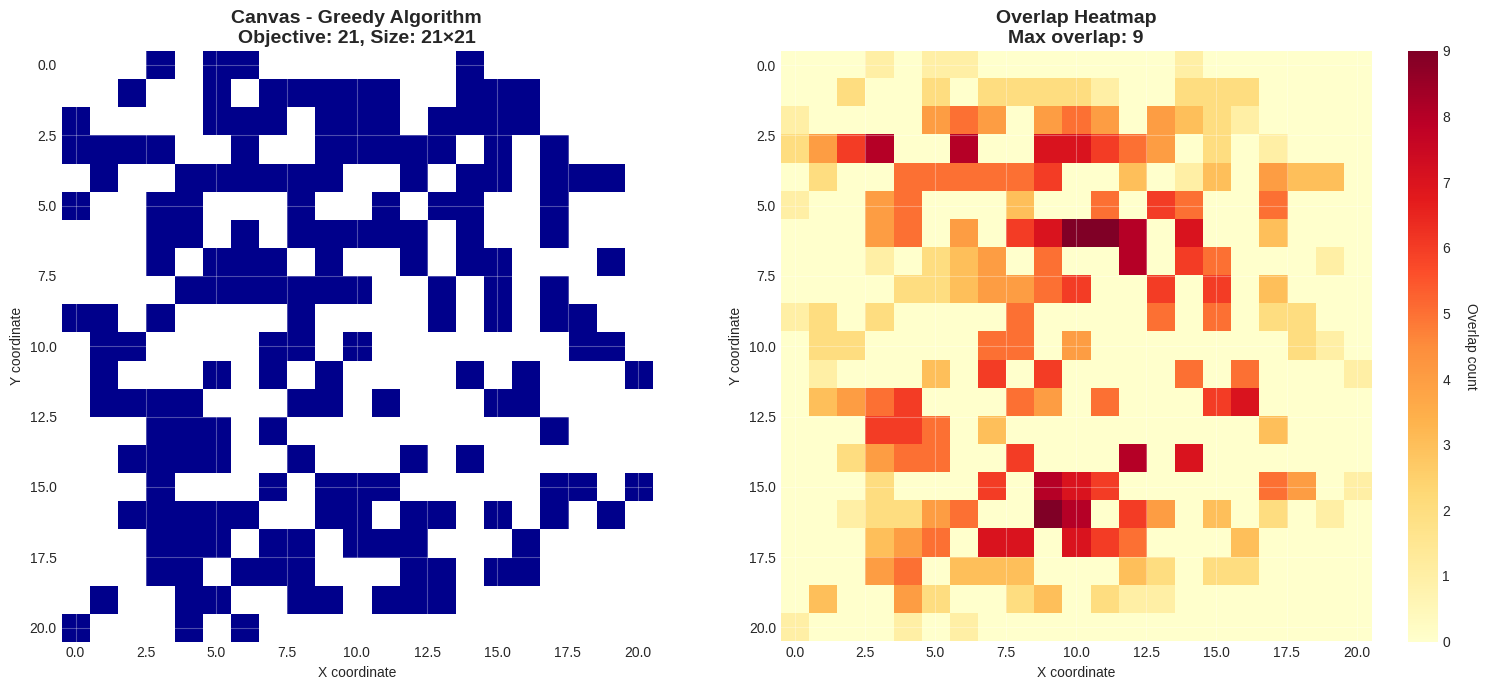

In [ ]:
# Convert canvas dictionary to 2D array for visualization
if canvas:
    min_x = min(x for x, y in canvas.keys())
    max_x = max(x for x, y in canvas.keys())
    min_y = min(y for x, y in canvas.keys())
    max_y = max(y for x, y in canvas.keys())
    
    width = max_x - min_x + 1
    height = max_y - min_y + 1
    
    print(f"Canvas bounds: x=[{min_x}, {max_x}], y=[{min_y}, {max_y}]")
    print(f"Canvas size: {width} × {height}")
    
    # Create binary canvas (0 = empty, 1 = filled)
    binary_canvas = np.zeros((height, width), dtype=int)
    
    for (x, y), value in canvas.items():
        canvas_x = x - min_x
        canvas_y = y - min_y
        binary_canvas[canvas_y, canvas_x] = value
    
    # Create overlap canvas
    overlap_array = np.zeros((height, width), dtype=int)
    
    for (x, y), count in overlap_count.items():
        canvas_x = x - min_x
        canvas_y = y - min_y
        overlap_array[canvas_y, canvas_x] = count
    
    # Plot binary canvas
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Binary canvas
    cmap_binary = ListedColormap(['white', 'darkblue'])
    im1 = axes[0].imshow(binary_canvas, cmap=cmap_binary, interpolation='nearest')
    axes[0].set_title(f'Canvas - {algorithm} Algorithm\nObjective: {objective}, Size: {width}×{height}', 
                     fontsize=14, fontweight='bold')
    axes[0].set_xlabel('X coordinate')
    axes[0].set_ylabel('Y coordinate')
    axes[0].grid(True, alpha=0.3)
    
    # Overlap heatmap
    im2 = axes[1].imshow(overlap_array, cmap='YlOrRd', interpolation='nearest')
    axes[1].set_title(f'Overlap Heatmap\nMax overlap: {max_overlap}', 
                     fontsize=14, fontweight='bold')
    axes[1].set_xlabel('X coordinate')
    axes[1].set_ylabel('Y coordinate')
    cbar = plt.colorbar(im2, ax=axes[1])
    cbar.set_label('Overlap count', rotation=270, labelpad=20)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## 6. Visualize Binary Canvas (0s and 1s)

Show the canvas as binary values where tiles are represented.

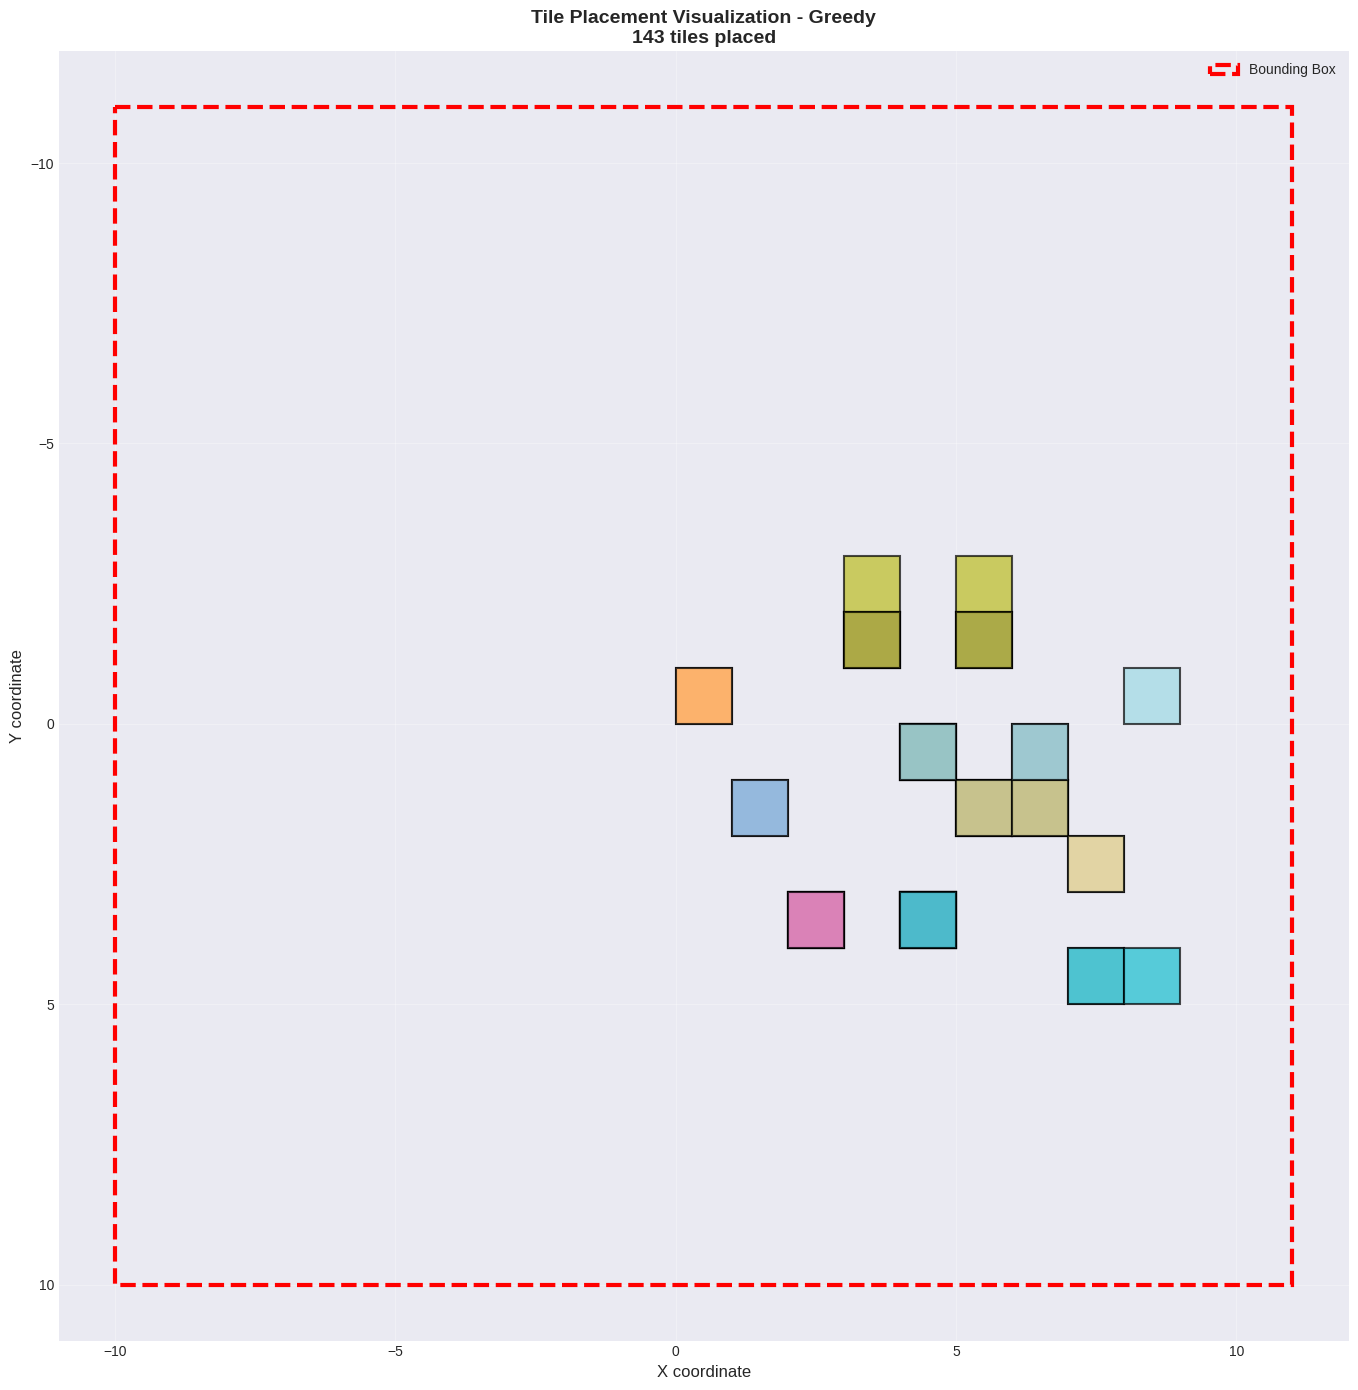

Showing first 20 of 143 tiles


In [ ]:
# Visualize individual tile placements with bounding box
fig, ax = plt.subplots(figsize=(14, 14))

# Draw canvas grid
ax.set_xlim(min_x - 1, max_x + 2)
ax.set_ylim(max_y + 2, min_y - 1)  # Inverted y-axis for standard visualization
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('X coordinate', fontsize=12)
ax.set_ylabel('Y coordinate', fontsize=12)
ax.set_title(f'Tile Placement Visualization - {algorithm}\n{len(placements)} tiles placed', 
            fontsize=14, fontweight='bold')

# Color map for tiles (using different colors for visibility)
colors = plt.cm.tab20(np.linspace(0, 1, min(20, len(placements))))

# Draw each tile
for idx, placement in enumerate(placements[:20]):  # Limit to first 20 for clarity
    tile_id = placement['tile_id']
    pos_x = placement['x']
    pos_y = placement['y']
    tile = tiles_data[tile_id]
    
    color = colors[idx % len(colors)]
    
    # Draw each cell of the tile
    for row_idx, row in enumerate(tile):
        for col_idx, cell_value in enumerate(row):
            if cell_value == 1:
                x = pos_x + col_idx
                y = pos_y + row_idx
                rect = patches.Rectangle((x, y), 1, 1, linewidth=1.5, 
                                        edgecolor='black', facecolor=color, alpha=0.7)
                ax.add_patch(rect)

# Draw bounding box
bbox_x_min = min_x
bbox_y_min = min_y
bbox_rect = patches.Rectangle((bbox_x_min, bbox_y_min), bbox_width, bbox_height,
                              linewidth=3, edgecolor='red', facecolor='none', 
                              linestyle='--', label='Bounding Box')
ax.add_patch(bbox_rect)

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Showing first 20 of {len(placements)} tiles")


## 7. Visualize Individual Tiles

Show the first few tiles from the dataset and their placements.

Tile Usage Statistics:
Tile ID    Usage Count     Percentage     
------------------------------------------------------------
0          1                 0.70%
5          1                 0.70%
6          1                 0.70%
1          1                 0.70%
2          1                 0.70%
7          1                 0.70%
8          1                 0.70%
9          1                 0.70%
3          1                 0.70%
10         1                 0.70%
... and 133 more tiles


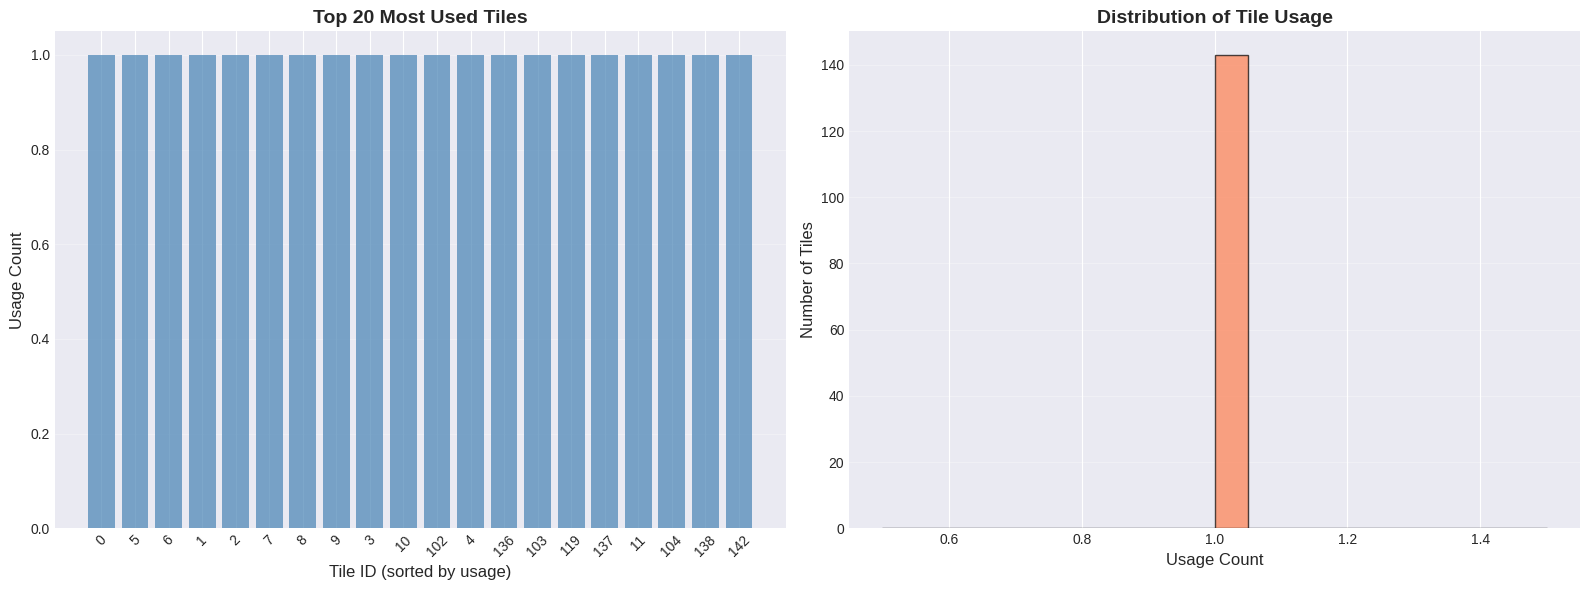

In [ ]:
# Analyze tile usage statistics
tile_usage = defaultdict(int)

for placement in placements:
    tile_usage[placement['tile_id']] += 1

# Sort by usage
sorted_tiles = sorted(tile_usage.items(), key=lambda x: x[1], reverse=True)

print("Tile Usage Statistics:")
print("=" * 60)
print(f"{'Tile ID':<10} {'Usage Count':<15} {'Percentage':<15}")
print("-" * 60)

for tile_id, count in sorted_tiles[:10]:  # Top 10
    percentage = (count / len(placements)) * 100
    print(f"{tile_id:<10} {count:<15} {percentage:>6.2f}%")

if len(sorted_tiles) > 10:
    print(f"... and {len(sorted_tiles) - 10} more tiles")

# Plot usage distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of top tiles
n_display = min(20, len(sorted_tiles))
tile_ids = [tid for tid, _ in sorted_tiles[:n_display]]
usage_counts = [count for _, count in sorted_tiles[:n_display]]

ax1.bar(range(n_display), usage_counts, color='steelblue', alpha=0.7)
ax1.set_xlabel('Tile ID (sorted by usage)', fontsize=12)
ax1.set_ylabel('Usage Count', fontsize=12)
ax1.set_title(f'Top {n_display} Most Used Tiles', fontsize=14, fontweight='bold')
ax1.set_xticks(range(n_display))
ax1.set_xticklabels(tile_ids, rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Histogram of usage distribution
ax2.hist(list(tile_usage.values()), bins=20, color='coral', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Usage Count', fontsize=12)
ax2.set_ylabel('Number of Tiles', fontsize=12)
ax2.set_title('Distribution of Tile Usage', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 8. Solution Statistics

Display detailed statistics about the solution.

Example Tiles Used in Solution:

Tile 0 (used 1 times):
   0 0 0 0 1
   0 1 0 0 0

Tile 5 (used 1 times):
   0 1 0 0 0
   0 0 0 0 0

Tile 6 (used 1 times):
   1 0 0 0 0
   0 0 0 0 1

Tile 1 (used 1 times):
   0 0 0 1 0
   1 0 0 0 0

Tile 2 (used 1 times):
   0 0 1 0 1
   0 0 0 0 0


IndexError: index 2 is out of bounds for axis 0 with size 2

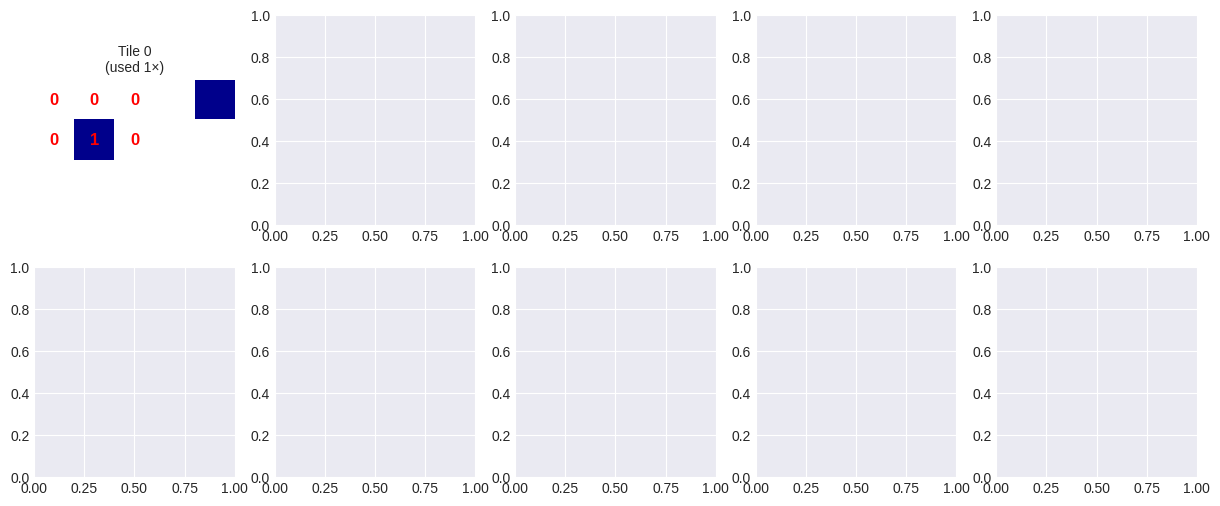

In [ ]:
# Display some example tiles that are used
print("Example Tiles Used in Solution:")
print("=" * 60)

for i, (tile_id, count) in enumerate(sorted_tiles[:5]):
    tile = tiles_data[tile_id]
    print(f"\nTile {tile_id} (used {count} times):")
    for row in tile:
        print("  ", " ".join(str(cell) for cell in row))

# Visualize example tiles
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, (tile_id, count) in enumerate(sorted_tiles[:10]):
    tile = tiles_data[tile_id]
    tile_array = np.array(tile)
    
    ax = axes[idx]
    cmap = ListedColormap(['white', 'darkblue'])
    ax.imshow(tile_array, cmap=cmap, interpolation='nearest')
    ax.set_title(f'Tile {tile_id}\n(used {count}×)', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, color='gray', linewidth=0.5, alpha=0.5)
    
    # Add cell values
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(tile_array[i, j]), 
                   ha='center', va='center', color='red', fontsize=12, fontweight='bold')

plt.suptitle('Top 10 Most Frequently Used Tiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Placement Density Heatmap

Visualize where tiles are most densely placed on the canvas.

In [ ]:
# Summary statistics
print("=" * 80)
print("SOLUTION SUMMARY")
print("=" * 80)
print(f"Algorithm:                {algorithm}")
print(f"Objective (L):            {objective}")
print(f"Bounding Box:             {bbox_width} × {bbox_height}")
print(f"Bounding Box Area:        {result['bbox_area']}")
print(f"Runtime:                  {result['runtime_seconds']:.6f} seconds")
print(f"Tiles Placed:             {len(placements)}")
print(f"Unique Tiles Used:        {len(tile_usage)}")
print(f"Canvas Cells Occupied:    {len(canvas)}")
print(f"Cells with Overlaps:      {sum(1 for count in overlap_count.values() if count > 1)}")
print(f"Maximum Overlap:          {max_overlap}")
print(f"Solution Verified:        {result.get('verified', 'N/A')}")
print("=" * 80)

# Additional analysis
if len(tile_usage) > 0:
    avg_usage = sum(tile_usage.values()) / len(tile_usage)
    print(f"\nAverage Usage per Tile:   {avg_usage:.2f}")
    print(f"Most Used Tile:           Tile {sorted_tiles[0][0]} ({sorted_tiles[0][1]} times)")
    print(f"Least Used Tile:          Tile {sorted_tiles[-1][0]} ({sorted_tiles[-1][1]} times)")

# Display raw canvas string if available
if 'canvas' in result and result['canvas']:
    print("\n" + "=" * 80)
    print("RAW CANVAS OUTPUT FROM SOLVER:")
    print("=" * 80)
    canvas_str = result['canvas'].replace('\\n', '\n').replace('\\t', '\t')
    print(canvas_str)
    print("=" * 80)


SOLUTION SUMMARY
Algorithm:                Genetic
Objective (L):            14
Bounding Box:             14 × 14
Bounding Box Area:        196
Runtime:                  20.123114 seconds
Tiles Placed:             80
Unique Tiles Used:        80
Canvas Cells Occupied:    91
Cells with Overlaps:      72
Maximum Overlap:          11
Solution Verified:        True

Average Usage per Tile:   1.00
Most Used Tile:           Tile 62 (1 times)
Least Used Tile:          Tile 38 (1 times)

RAW CANVAS OUTPUT FROM SOLVER:
1 1 0 0 1 . 1 1 0 0 . . . .
1 1 1 1 0 1 0 1 0 1 1 . . .
0 0 1 0 0 0 1 1 0 1 1 1 0 0
. 0 0 0 0 1 1 1 1 0 0 0 0 1
1 0 1 1 1 0 0 1 1 0 1 0 1 0
1 1 0 1 0 1 0 0 1 1 0 1 1 0
0 1 0 1 1 1 1 1 1 1 0 0 0 0
. . . 1 0 1 0 0 1 0 0 1 0 0
. . 1 0 1 1 1 0 0 1 0 0 0 1
. . 1 1 1 1 1 0 0 1 1 0 0 0
. 1 1 1 1 0 1 1 0 1 0 0 1 0
. 0 0 1 0 1 1 0 0 0 1 1 0 1
. 0 1 1 1 0 1 1 0 0 . 0 1 0
. 0 1 1 0 0 0 1 1 0 . 1 0 1


## 7. Detailed Tile Placement with Bounding Boxes

Show each tile with its position and individual bounding box.

In [ ]:
# Calculate bounding box for each tile placement
def get_tile_bounds(tile, pos_x, pos_y):
    """Calculate the bounding box for a tile at a given position."""
    min_x, max_x = float('inf'), float('-inf')
    min_y, max_y = float('inf'), float('-inf')
    
    for row_idx, row in enumerate(tile):
        for col_idx, cell_value in enumerate(row):
            if cell_value == 1:
                x = pos_x + col_idx
                y = pos_y + row_idx
                min_x = min(min_x, x)
                max_x = max(max_x, x)
                min_y = min(min_y, y)
                max_y = max(max_y, y)
    
    if min_x == float('inf'):  # Empty tile
        return None
    
    width = max_x - min_x + 1
    height = max_y - min_y + 1
    return {
        'min_x': min_x, 'max_x': max_x,
        'min_y': min_y, 'max_y': max_y,
        'width': width, 'height': height
    }

# Analyze each tile placement
tile_info = []
for placement in placements:
    tile_id = placement['tile_id']
    pos_x = placement['x']
    pos_y = placement['y']
    tile = tiles_data[tile_id]
    
    bounds = get_tile_bounds(tile, pos_x, pos_y)
    if bounds:
        tile_info.append({
            'tile_id': tile_id,
            'position': (pos_x, pos_y),
            'bounds': bounds,
            'tile': tile
        })

print(f"Analyzed {len(tile_info)} tile placements")
print(f"\nFirst 10 tiles with position and bounding box:")
print("=" * 80)
for i, info in enumerate(tile_info[:10]):
    b = info['bounds']
    print(f"Tile {info['tile_id']}:")
    print(f"  Position: ({info['position'][0]}, {info['position'][1]})")
    print(f"  Bounding Box: [{b['min_x']}, {b['max_x']}] × [{b['min_y']}, {b['max_y']}]")
    print(f"  Size: {b['width']} × {b['height']}")
    print()

Analyzed 80 tile placements

First 10 tiles with position and bounding box:
Tile 62:
  Position: (-10, -3)
  Bounding Box: [-10, -8] × [-3, -1]
  Size: 3 × 3

Tile 61:
  Position: (-10, -7)
  Bounding Box: [-10, -8] × [-7, -5]
  Size: 3 × 3

Tile 79:
  Position: (-8, -7)
  Bounding Box: [-8, -6] × [-7, -5]
  Size: 3 × 3

Tile 66:
  Position: (-3, -7)
  Bounding Box: [-3, -1] × [-7, -5]
  Size: 3 × 3

Tile 65:
  Position: (-4, -7)
  Bounding Box: [-4, -3] × [-7, -5]
  Size: 2 × 3

Tile 67:
  Position: (-9, 4)
  Bounding Box: [-8, -7] × [4, 6]
  Size: 2 × 3

Tile 64:
  Position: (-9, 3)
  Bounding Box: [-9, -7] × [3, 5]
  Size: 3 × 3

Tile 77:
  Position: (-9, -4)
  Bounding Box: [-9, -7] × [-3, -2]
  Size: 3 × 2

Tile 74:
  Position: (-9, -5)
  Bounding Box: [-8, -7] × [-5, -3]
  Size: 2 × 3

Tile 71:
  Position: (-9, -6)
  Bounding Box: [-9, -7] × [-6, -5]
  Size: 3 × 2



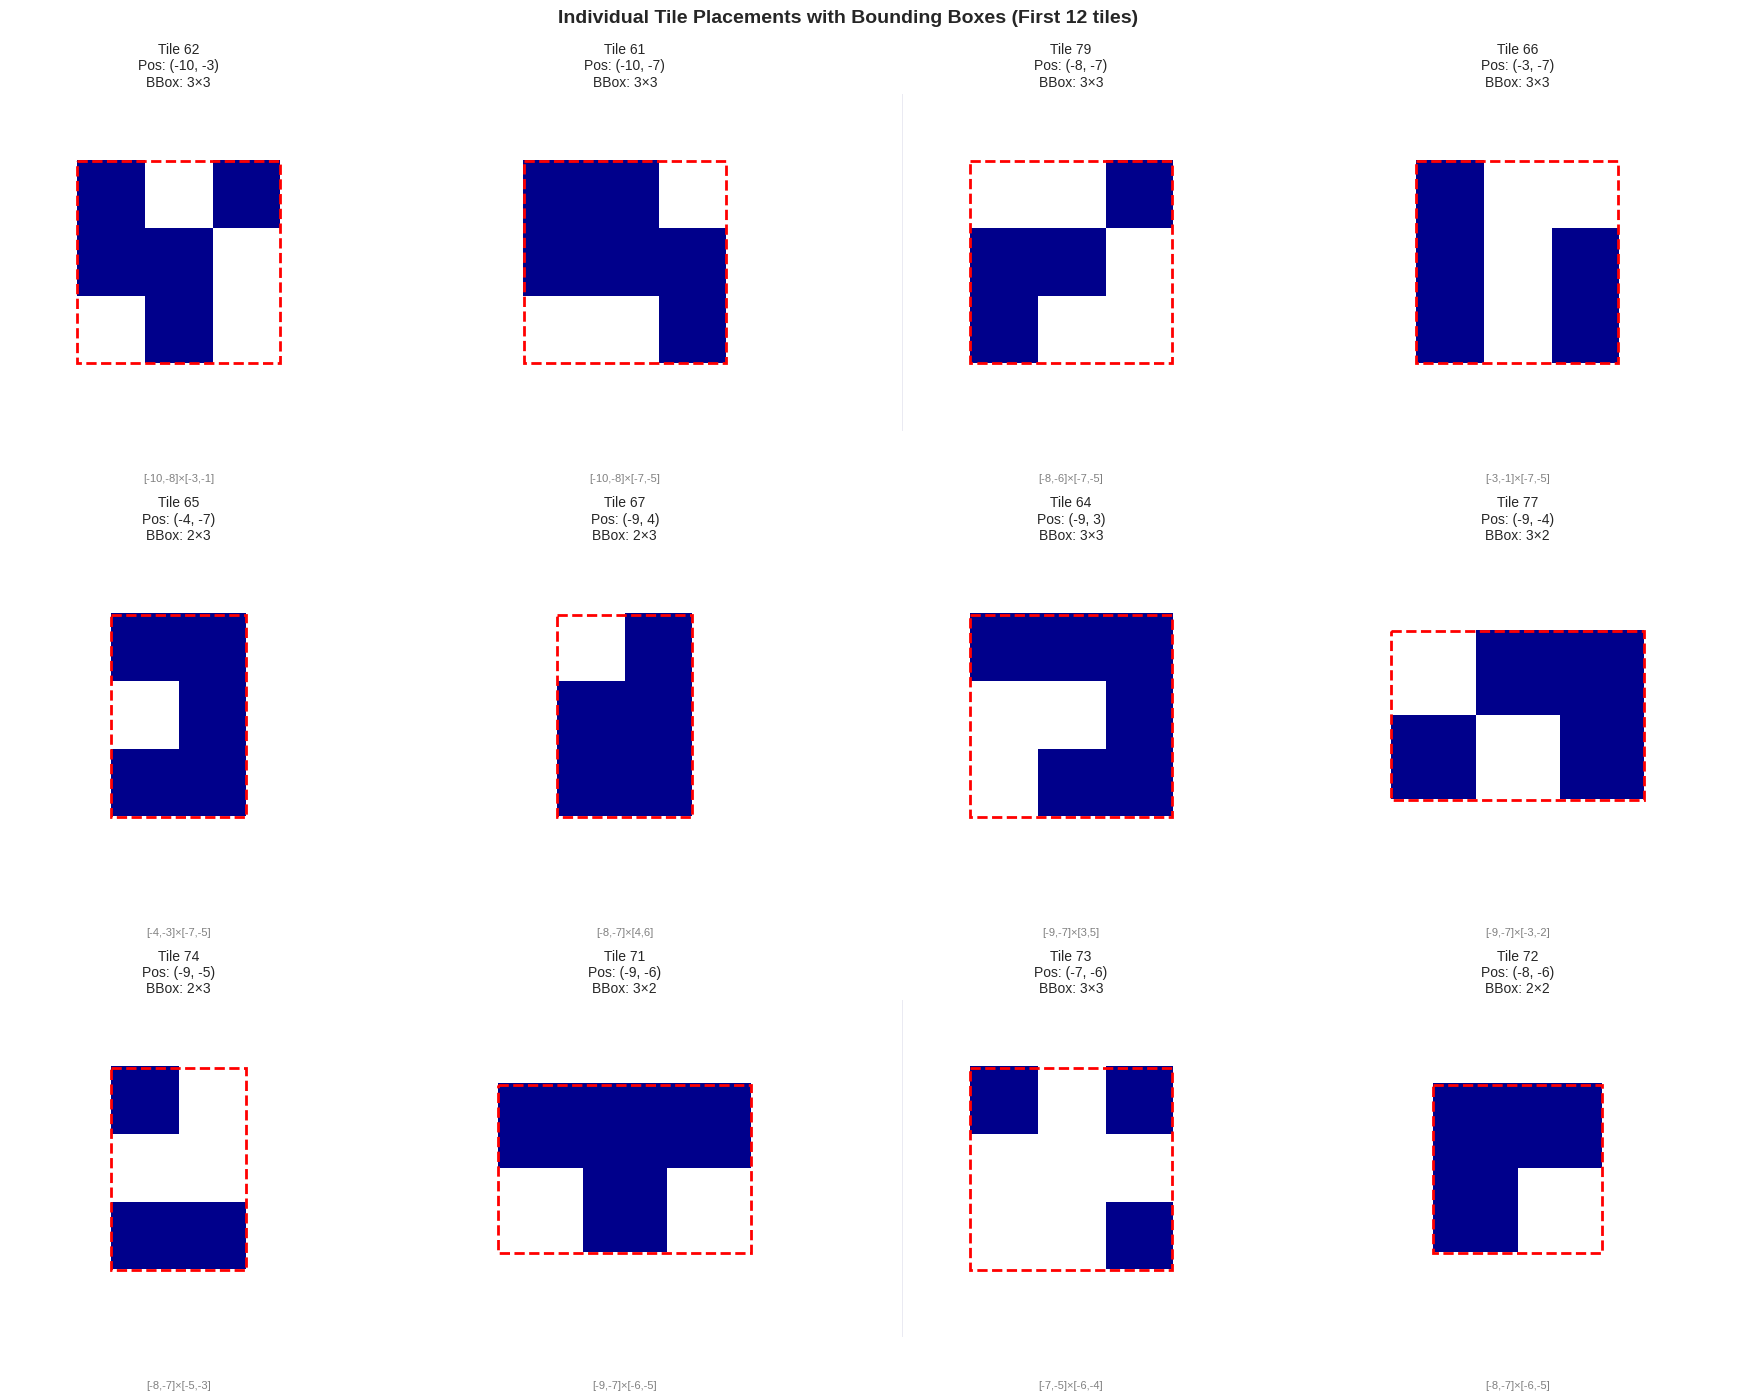

In [ ]:
# Visualize individual tiles with their bounding boxes
n_to_show = 12  # Show first 12 tiles
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()

cmap_tile = ListedColormap(['white', 'darkblue'])

for idx in range(min(n_to_show, len(tile_info))):
    info = tile_info[idx]
    ax = axes[idx]
    
    # Calculate local bounds for visualization
    tile_id = info['tile_id']
    pos_x, pos_y = info['position']
    bounds = info['bounds']
    
    # Create a small canvas for this tile
    tile_width = bounds['max_x'] - bounds['min_x'] + 3  # Add padding
    tile_height = bounds['max_y'] - bounds['min_y'] + 3
    local_canvas = np.zeros((tile_height, tile_width))
    
    # Draw the tile
    tile = info['tile']
    for row_idx, row in enumerate(tile):
        for col_idx, cell_value in enumerate(row):
            if cell_value == 1:
                x = pos_x + col_idx - bounds['min_x'] + 1
                y = pos_y + row_idx - bounds['min_y'] + 1
                local_canvas[y, x] = 1
    
    # Display
    ax.imshow(local_canvas, cmap=cmap_tile, interpolation='nearest')
    
    # Draw bounding box in local coordinates
    bbox_local_x = 1
    bbox_local_y = 1
    bbox_rect = patches.Rectangle(
        (bbox_local_x - 0.5, bbox_local_y - 0.5),
        bounds['width'], bounds['height'],
        linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
    )
    ax.add_patch(bbox_rect)
    
    # Add title with information
    ax.set_title(
        f"Tile {tile_id}\n"
        f"Pos: ({pos_x}, {pos_y})\n"
        f"BBox: {bounds['width']}×{bounds['height']}",
        fontsize=10
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, alpha=0.3, linewidth=0.5)
    
    # Add position annotation
    ax.text(0.5, -0.15, f"[{bounds['min_x']},{bounds['max_x']}]×[{bounds['min_y']},{bounds['max_y']}]",
           transform=ax.transAxes, ha='center', fontsize=8, color='gray')

# Hide unused subplots
for idx in range(min(n_to_show, len(tile_info)), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Individual Tile Placements with Bounding Boxes (First {n_to_show} tiles)', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

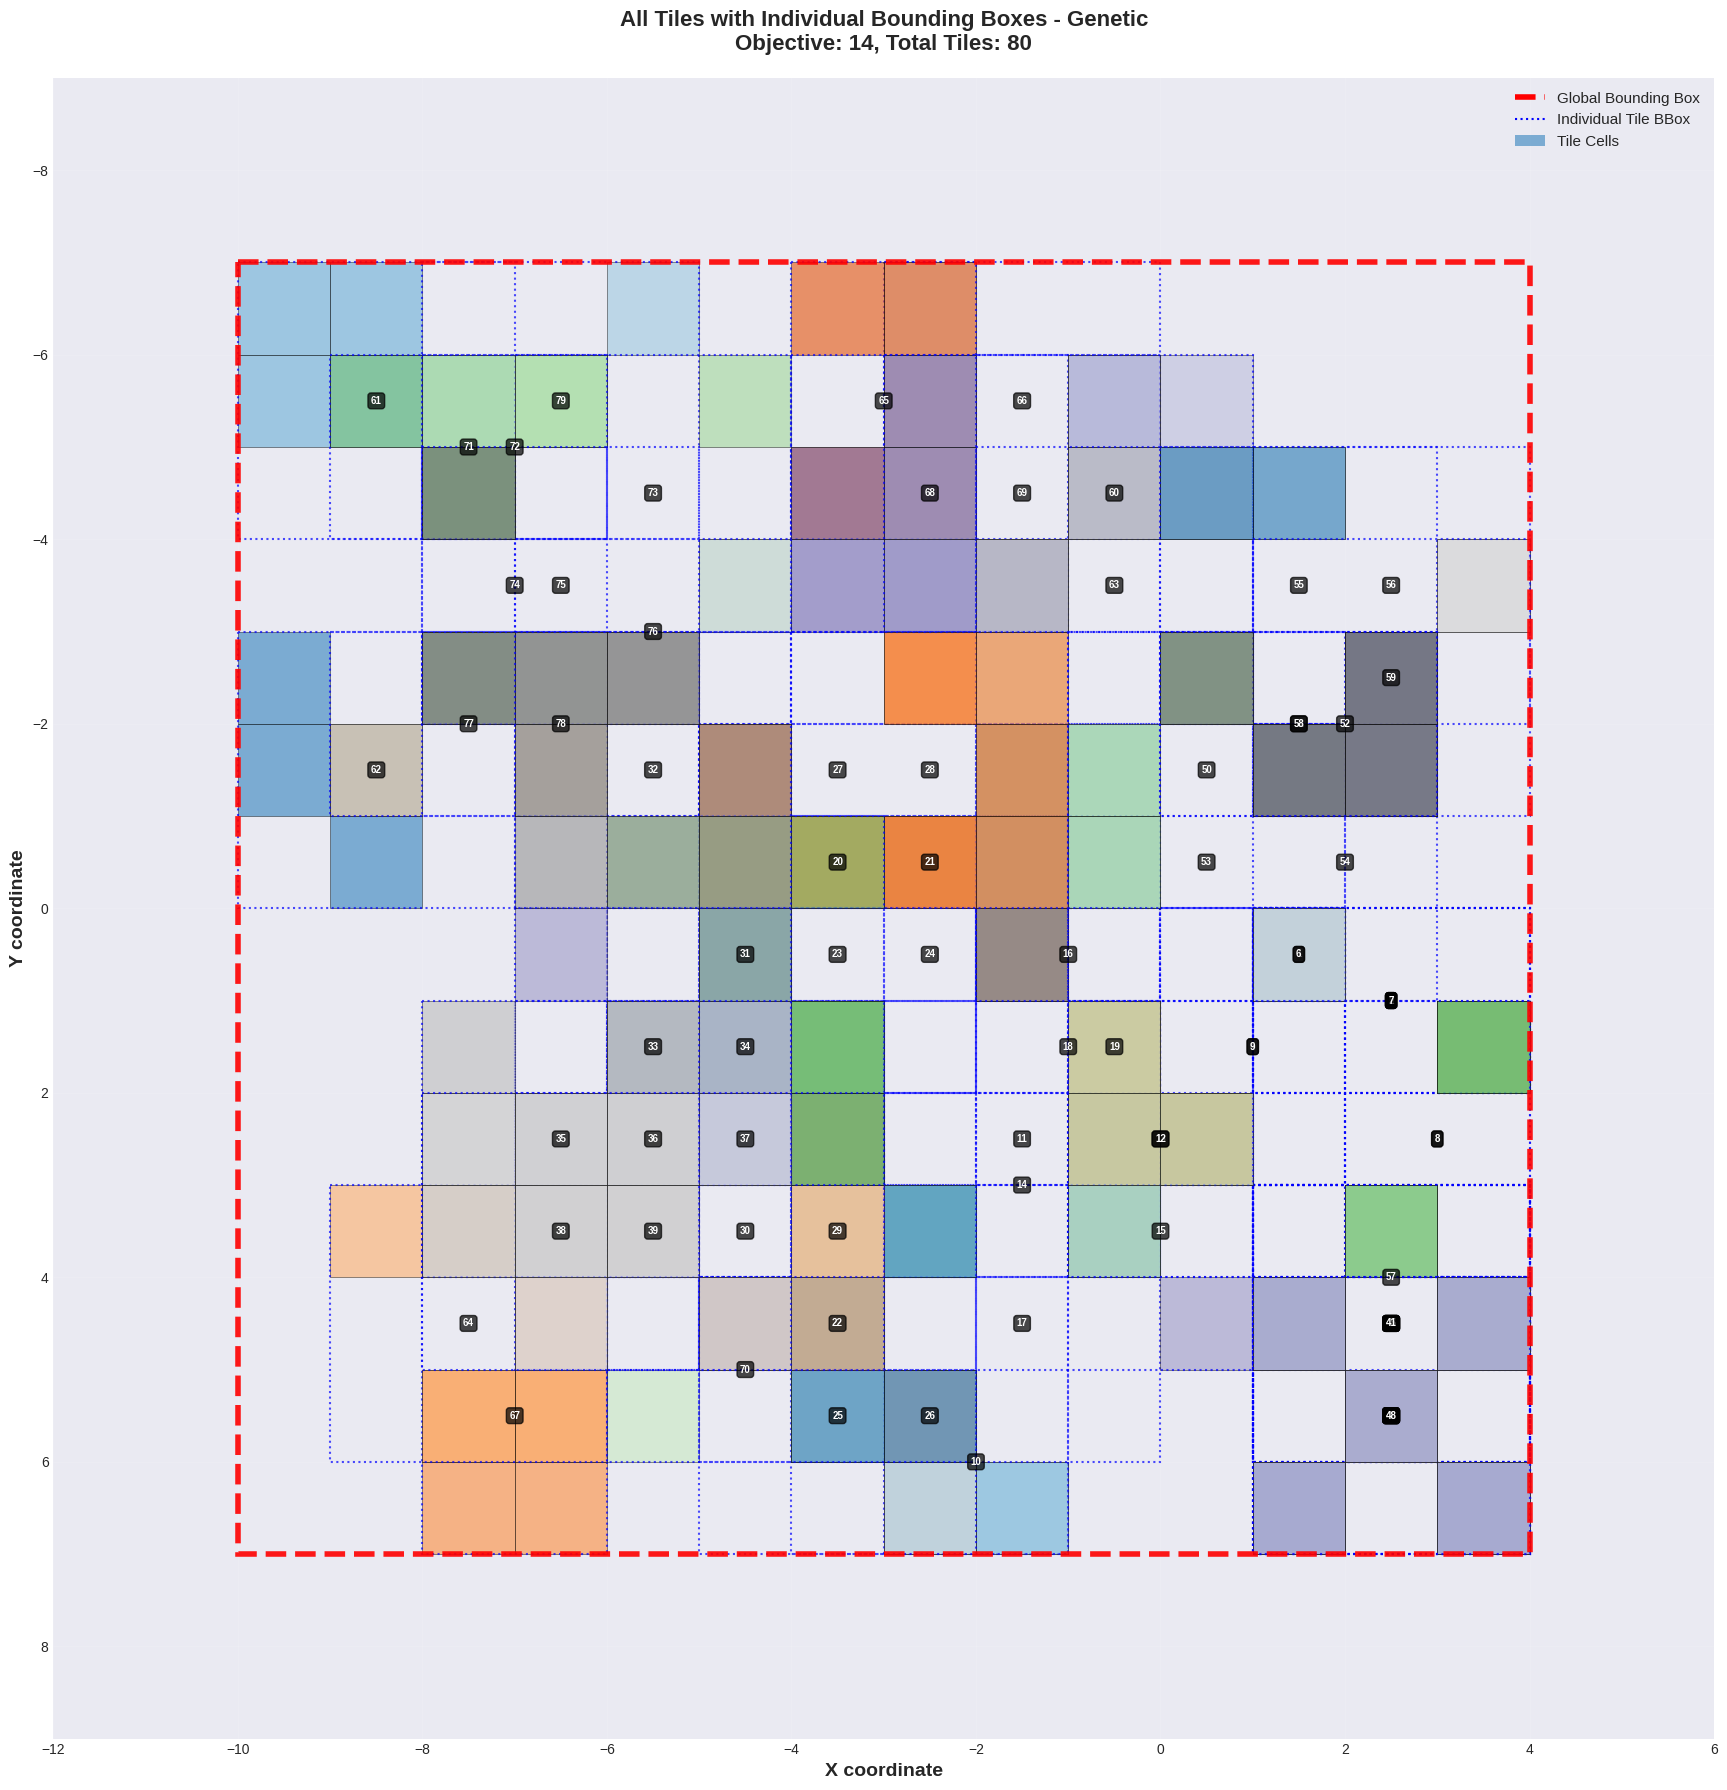


Showing all 80 tiles with individual bounding boxes (blue dotted)
Global bounding box shown in red dashed line
Each tile labeled with its ID number


In [ ]:
# Create a comprehensive view showing all tiles with labels
fig, ax = plt.subplots(figsize=(18, 18))

# Set up the plot
ax.set_xlim(min_x - 2, max_x + 3)
ax.set_ylim(max_y + 3, min_y - 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2, linewidth=0.5)
ax.set_xlabel('X coordinate', fontsize=14, fontweight='bold')
ax.set_ylabel('Y coordinate', fontsize=14, fontweight='bold')
ax.set_title(f'All Tiles with Individual Bounding Boxes - {algorithm}\n'
            f'Objective: {objective}, Total Tiles: {len(tile_info)}', 
            fontsize=16, fontweight='bold', pad=20)

# Color map
colors = plt.cm.tab20c(np.linspace(0, 1, 20))

# Draw each tile with its bounding box
for idx, info in enumerate(tile_info):
    tile_id = info['tile_id']
    pos_x, pos_y = info['position']
    tile = info['tile']
    bounds = info['bounds']
    
    color = colors[idx % len(colors)]
    
    # Draw tile cells
    for row_idx, row in enumerate(tile):
        for col_idx, cell_value in enumerate(row):
            if cell_value == 1:
                x = pos_x + col_idx
                y = pos_y + row_idx
                rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5,
                                        edgecolor='black', facecolor=color, alpha=0.6)
                ax.add_patch(rect)
    
    # Draw individual bounding box for each tile
    bbox_rect = patches.Rectangle(
        (bounds['min_x'], bounds['min_y']),
        bounds['width'], bounds['height'],
        linewidth=1.5, edgecolor='blue', facecolor='none',
        linestyle=':', alpha=0.7
    )
    ax.add_patch(bbox_rect)
    
    # Add tile ID label at the center of its bounding box
    center_x = bounds['min_x'] + bounds['width'] / 2
    center_y = bounds['min_y'] + bounds['height'] / 2
    ax.text(center_x, center_y, str(tile_id), 
           ha='center', va='center', fontsize=7, fontweight='bold',
           color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

# Draw global bounding box
global_bbox = patches.Rectangle(
    (min_x, min_y), bbox_width, bbox_height,
    linewidth=4, edgecolor='red', facecolor='none',
    linestyle='--', label='Global Bounding Box', alpha=0.9
)
ax.add_patch(global_bbox)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linewidth=4, linestyle='--', label='Global Bounding Box'),
    Line2D([0], [0], color='blue', linewidth=1.5, linestyle=':', label='Individual Tile BBox'),
    patches.Rectangle((0, 0), 1, 1, facecolor=colors[0], alpha=0.6, label='Tile Cells')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"\nShowing all {len(tile_info)} tiles with individual bounding boxes (blue dotted)")
print(f"Global bounding box shown in red dashed line")
print(f"Each tile labeled with its ID number")